# DISCO Treatment Effect Demo â€” Synthetic Data

This notebook mirrors `te_auc_adult.ipynb` but uses the synthetic tabular dataset.

Before running the cells below, generate the required assets (devices + probe trajectories) â€” for example:

```bash
python -m disco.cli.main synth --p 8 --N 5 --m 500 --alpha 0.7 --theta0 "[0.0,0.25,0.5,0.75,1.0]" --theta "[1.2,1.3,1.4,1.5,1.6,1.7,1.8]" --K 30 --tau 0.5 --lam 0.01 --mode p --base-jitter 0.3 --peer-alpha-std 0.15 --noise-std 0.05 --out experiments/results/synth_run --seed 42

python -m disco.cli.main train-devices --dataset scenario --scenario experiments/results/synth_run/scenario.npz --samples 2000 --N 5 --out experiments/synth_devices --seed 42

python -m disco.cli.main probe --devices experiments/synth_devices --dataset scenario --scenario experiments/results/synth_run/scenario.npz --probes 200 --theta0 "[0.0,0.25,0.5,0.75,1.0]" --interventions experiments/configs/tabular_interventions.yaml --out experiments/results/synth_run/probes --seed 42

python -m disco.cli.main explain --devices experiments/synth_devices --probes experiments/results/synth_run/probes --dataset scenario --scenario experiments/results/synth_run/scenario.npz --targets 0 --queries 3 --interventions experiments/configs/tabular_interventions.yaml --K 30 --tau 0.5 --lam 0.01 --mode p --out experiments/results/synth_run/explain --seed 42
```

If you already have different synthetic assets, just point the paths below at them.


In [9]:
# Add parent directory to path
import sys
import os
sys.path.append(os.path.abspath('../..'))

In [ ]:
from pathlib import Path
import numpy as np

from disco.notebook_utils import (
    load_scenario_artifacts,
    compute_te_output_from_scenario,
)
from disco.interventions.grids import Grids
from disco.interventions.tabular import FeatureAdd,FeatureScale
from disco.counterfactual.pmode import PModeCounterfactual
import matplotlib.pyplot as plt

In [11]:
SCENARIO_DIR = Path('..').resolve() / 'results' / 'synth_run'
scenario, scenario_trajs = load_scenario_artifacts(SCENARIO_DIR)

In [67]:
intervention = FeatureAdd(feat_idx=7, delta_max=float(scenario.theta.max()), name='intensity_shift')
print(f'Using intervention: {intervention.name}')


Using intervention: intensity_shift


In [68]:
te_output, result = compute_te_output_from_scenario(
    scenario,
    intervention=intervention,
    mode='p',        # note: drop the trajectories argument
)

print(f'DISCO weights sum: {result["weights"].sum():.3f}')


DISCO weights sum: 1.000


In [69]:
theta_post = te_output.theta
weights_disco = result['weights']
_, _, tau_true = scenario.compute_tau(weights_disco, intervention, x=scenario.x_star, theta=theta_post)

w_avg = np.ones_like(weights_disco) / len(weights_disco)
_, _, tau_true_avg = scenario.compute_tau(w_avg, intervention, x=scenario.x_star, theta=theta_post)

pmode = PModeCounterfactual()
y_syn_avg_proxy, proxy_bias_avg = pmode.build(
    w=w_avg,
    devices=scenario.devices,
    X_probe=scenario.X_probe,
    anchor_sel=result['anchor_selection'],
    x_star=scenario.x_star,
    grids=Grids(theta0=scenario.theta0, theta=scenario.theta),
    intervention=intervention,
    target_device=scenario.devices[0],
    target_class=0,
)
tau_est_avg = te_output.y_t - y_syn_avg_proxy

print(f"max |tau_true - DISCO| = {np.max(np.abs(tau_true - te_output.tau)):.2e}")
print(f"max |tau_true_avg - tau_est_avg| = {np.max(np.abs(tau_true_avg - tau_est_avg)):.2e}")


max |tau_true - DISCO| = 1.09e+00
max |tau_true_avg - tau_est_avg| = 1.28e+00


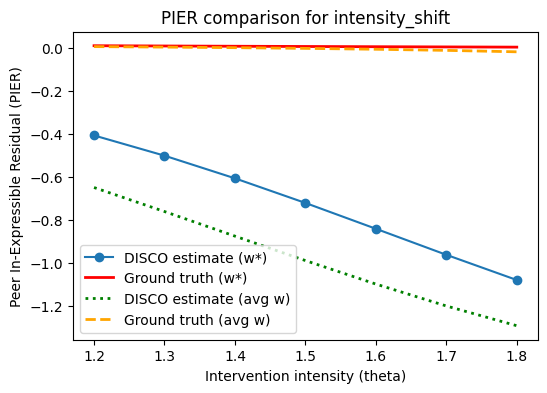

In [70]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(theta_post, te_output.tau, marker='o', color='C0', label='DISCO estimate (w*)')
ax.plot(theta_post, tau_true, color='red', linewidth=2, label='Ground truth (w*)')
ax.plot(theta_post, tau_est_avg, color='green', linestyle=':', linewidth=2, label='DISCO estimate (avg w)')
ax.plot(theta_post, tau_true_avg, color='orange', linestyle='--', linewidth=2, label='Ground truth (avg w)')
ax.set_xlabel('Intervention intensity (theta)')
ax.set_ylabel('Peer In-Expressible Residual (PIER)')
ax.set_title(f'PIER comparison for {intervention.name}')
ax.legend()
plt.show()
